# Proyek Analisis Data: [Input Nama Dataset]
- **Nama:** Salsabil Salwa Putri Maharani
- **Email:** salwa.maharani39@gmail.com / cdcc012d6x0994@student.devacademy.id
- **ID Dicoding:** CDCC012D6X0994

## Menentukan Pertanyaan Bisnis

- **Pertanyaan 1**: Bagaimana pola perilaku peminjaman antara pengguna biasa (Casual) dan pengguna terdaftar (Registered) berdasarkan tipe hari (Hari Kerja vs Hari Libur)?
- **Pertanyaan 2**: Bagaimana pengaruh kondisi cuaca terhadap jumlah peminjaman sepeda harian pada periode 2011–2012?

## Import Semua Packages/Library yang Digunakan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [2]:
df = pd.read_csv("data/hour.csv")

df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**

berhasil memuat dataset peminjaman sepeda, dengan menampilkan kolom seperti dateday, season, year, weathersit, temp, casual, registered dan cnt.


### Assessing Data

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [4]:
df.isna().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [5]:
df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Insight:**
- diketahui bahwa ada kolom yang tipe datanya tidak sesuai, yaitu kolom dateday yang masih menggunakan tipe data teks.
- ketika melakukan pengecekan missing value, diketahui bahwa dataset telah bersih
- pada deskripsi data, diketahui bahwa minimal peminjam yaitu 1 dan maksimal 997, dengan rata-rata 189,46 perjamnya.

### Cleaning Data

In [6]:
df['dteday'] = pd.to_datetime(df['dteday'])

df['dteday'].dtype

df['weather_label'] = df['weathersit'].map({1: 'Clear', 2: 'Misty/Cloudy', 3: 'Light Rain/Snow', 4: 'Heavy Rain/Snow'})
df['temp_category'] = pd.cut(df['temp'], bins=[0, 0.3, 0.6, 1.0], labels=['Dingin', 'Sedang', 'Panas'])
df['season_label'] = df['season'].map({1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'})
df['day_type'] = df['workingday'].map({0: 'Hari Libur/Weekend', 1: 'Hari Kerja'})
df['time_category'] = pd.cut(df['hr'], bins=[-1, 5, 11, 17, 23], labels=['Dini Hari', 'Pagi', 'Siang/Sore', 'Malam'])


In [7]:
df['weather_label'] = df['weathersit'].map({1: 'Clear', 2: 'Misty/Cloudy', 3: 'Light Rain/Snow', 4: 'Heavy Rain/Snow'})
df['temp_category'] = pd.cut(df['temp'], bins=[0, 0.3, 0.6, 1.0], labels=['Dingin', 'Sedang', 'Panas'])
df['season_label'] = df['season'].map({1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'})
df['day_type'] = df['workingday'].map({0: 'Hari Libur/Weekend', 1: 'Hari Kerja'})
df['time_category'] = pd.cut(df['hr'], bins=[-1, 5, 11, 17, 23], labels=['Dini Hari', 'Pagi', 'Siang/Sore', 'Malam'])

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
print("Cek Missing Values:\n", df.isna().sum())
print("\nCek Duplikat:", df.duplicated().sum())

Cek Missing Values:
 instant          0
dteday           0
season           0
yr               0
mnth             0
hr               0
holiday          0
weekday          0
workingday       0
weathersit       0
temp             0
atemp            0
hum              0
windspeed        0
casual           0
registered       0
cnt              0
weather_label    0
temp_category    0
season_label     0
day_type         0
time_category    0
dtype: int64

Cek Duplikat: 0


**Insight:**
- tidak ditemukannya data duplikat
- melakukan perubahan tipe data pada dateday, yang sebelumnya object menjadi datetime
- melakukan pengubahan kode numerik pada variabel weather, season, dan temp menjadi label

## Exploratory Data Analysis (EDA)

##Explore ...

In [10]:
df.describe()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2012-01-02 04:08:34.552045568,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
min,1.0000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2011-07-04 00:00:00,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,2012-01-02 00:00:00,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,2012-07-02 00:00:00,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000
std,5017.0295,NaN,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599


In [11]:

corr_matrix = df.corr(numeric_only=True)

print("--- Korelasi Fitur Numerik terhadap Jumlah Peminjaman ---")
print(corr_matrix[['cnt', 'temp', 'hum']].sort_values(by='cnt', ascending=False))


--- Korelasi Fitur Numerik terhadap Jumlah Peminjaman ---
                 cnt      temp       hum
cnt         1.000000  0.404772 -0.322911
registered  0.972151  0.335361 -0.273933
casual      0.694564  0.459616 -0.347028
temp        0.404772  1.000000 -0.069881
atemp       0.400929  0.987672 -0.051918
hr          0.394071  0.137603 -0.276498
instant     0.278379  0.136178  0.009577
yr          0.250495  0.040913 -0.083546
season      0.178056  0.312025  0.150625
mnth        0.120638  0.201691  0.164411
windspeed   0.093234 -0.023125 -0.290105
workingday  0.030284  0.055390  0.015688
weekday     0.026900 -0.001795 -0.037158
holiday    -0.030927 -0.027340 -0.010588
weathersit -0.142426 -0.102640  0.418130
hum        -0.322911 -0.069881  1.000000


In [12]:
df.groupby(by="season").agg({
    "cnt": ["max", "min", "mean", "std"],
    "casual": "sum",
    "registered": "sum"
})

cnt                              casual registered
        max min        mean         std     sum        sum
season                                                    
1       801   1  111.114569  119.224010   60622     410726
2       957   1  208.344069  188.362473  203522     715067
3       977   1  236.016237  197.711630  226091     835038
4       967   1  198.868856  182.967972  129782     711831

In [13]:
df.groupby(by="weathersit").cnt.mean().sort_values(ascending=False)

weathersit
1    204.869272
2    175.165493
3    111.579281
4     74.333333
Name: cnt, dtype: float64

In [14]:
daytype_df = df.groupby("day_type", observed=True).agg({
    "casual": "mean",
    "registered": "mean"
}).reset_index()

**Insight:**
- berdasarkan matriks korelasi, variabel temp memiliki koefisien korelasi positif sebesar 0.404 terhadap total peminjaman (cnt) yang berarti semakin tinggi suhu semakin meningkat jumlah peminjaman sepeda. sedangkan variabel hum menunjukkan nilai korelasi negatif sebesar -0.322 terhadap cnt yang mengindikasikan bahwa tingkat kelembapan yang tinggi menjadi faktor buruk bagi pengguna untuk meminjam sepeda. dan di variabel jam emiliki korelasi positif sebesar 0.394, menunjukkan adanya fluktuasi peminjaman yang signifikan pada jam-jam tertentu dalam sehari (seperti jam berangkat/pulang kerja).
- hasil agregasi menunjukkan bahwa season 3 merupakan periode paling produktif dengan rata-rata peminjaman tertinggi 236.01 dan yang terendah pada season 1 dengan rata-rata 111.1


## Visualization & Explanatory Analysis

### Pertanyaan 1:

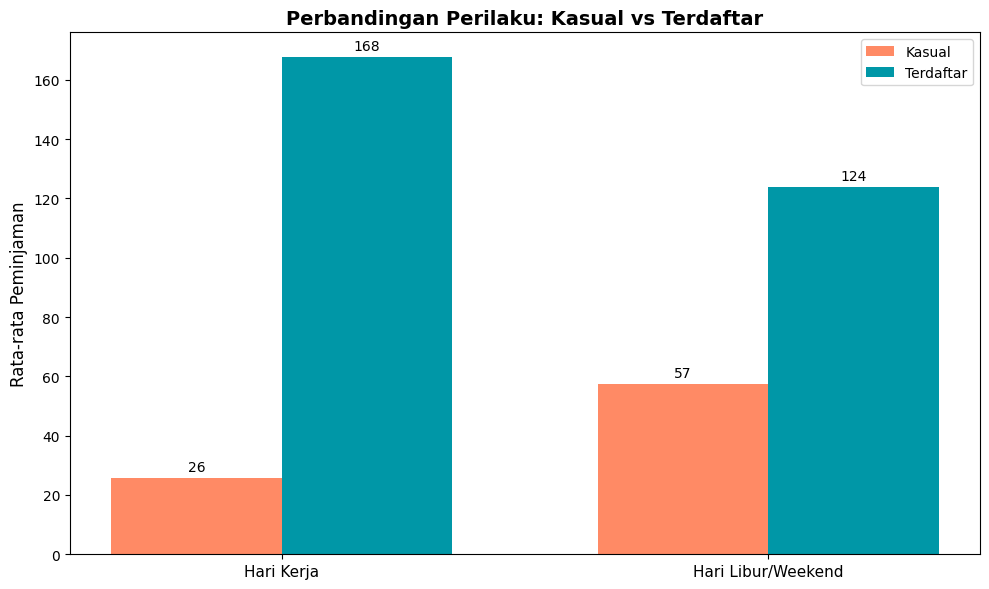

In [15]:
day_type_map = {0: 'Hari Libur/Weekend', 1: 'Hari Kerja'}
if 'day_type' not in df.columns:
    df['day_type'] = df['workingday'].map(day_type_map)

user_behavior_df = df.groupby('day_type', observed=True)[['casual', 'registered']].mean().reset_index()
labels = user_behavior_df['day_type']
casual_means = user_behavior_df['casual']
registered_means = user_behavior_df['registered']
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, casual_means, width, label='Kasual', color='#FF8A65')
rects2 = ax.bar(x + width/2, registered_means, width, label='Terdaftar', color='#0097A7')

ax.set_ylabel('Rata-rata Peminjaman', fontsize=12)
ax.set_title('Perbandingan Perilaku: Kasual vs Terdaftar', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.legend()

for bars in [rects1, rects2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.0f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

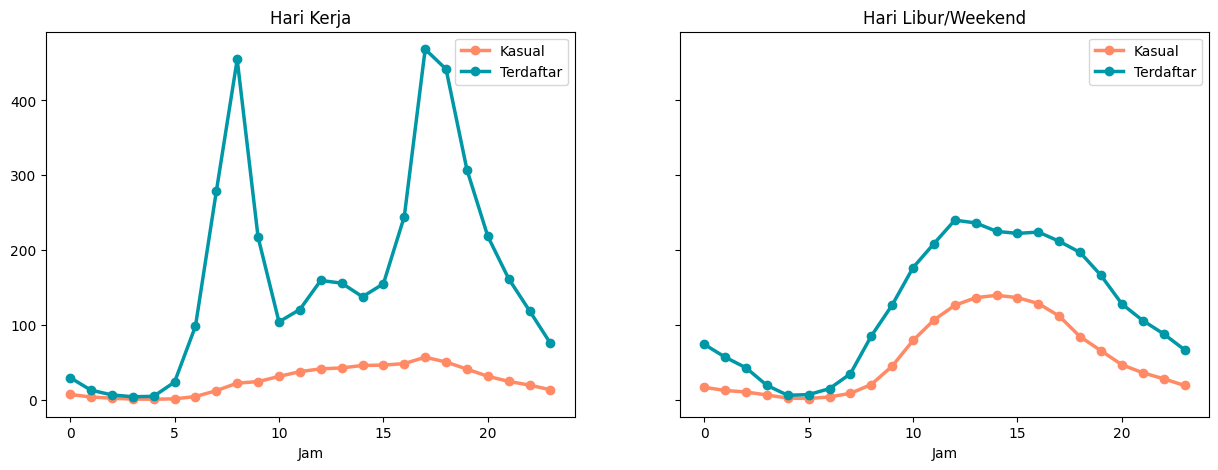

In [16]:
hourly_behavior = df.groupby(['day_type', 'hr'], observed=True)[['casual', 'registered']].mean().reset_index()

fig2, axes2 = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for i, dtype in enumerate(['Hari Kerja', 'Hari Libur/Weekend']):
        data = hourly_behavior[hourly_behavior['day_type'] == dtype]
        axes2[i].plot(data['hr'], data['casual'], label='Kasual', color='#FF8A65', linewidth=2.5, marker='o')
        axes2[i].plot(data['hr'], data['registered'], label='Terdaftar', color='#0097A7', linewidth=2.5, marker='o')
        axes2[i].set_title(dtype)
        axes2[i].set_xlabel("Jam")
        axes2[i].legend()


### Pertanyaan 2:

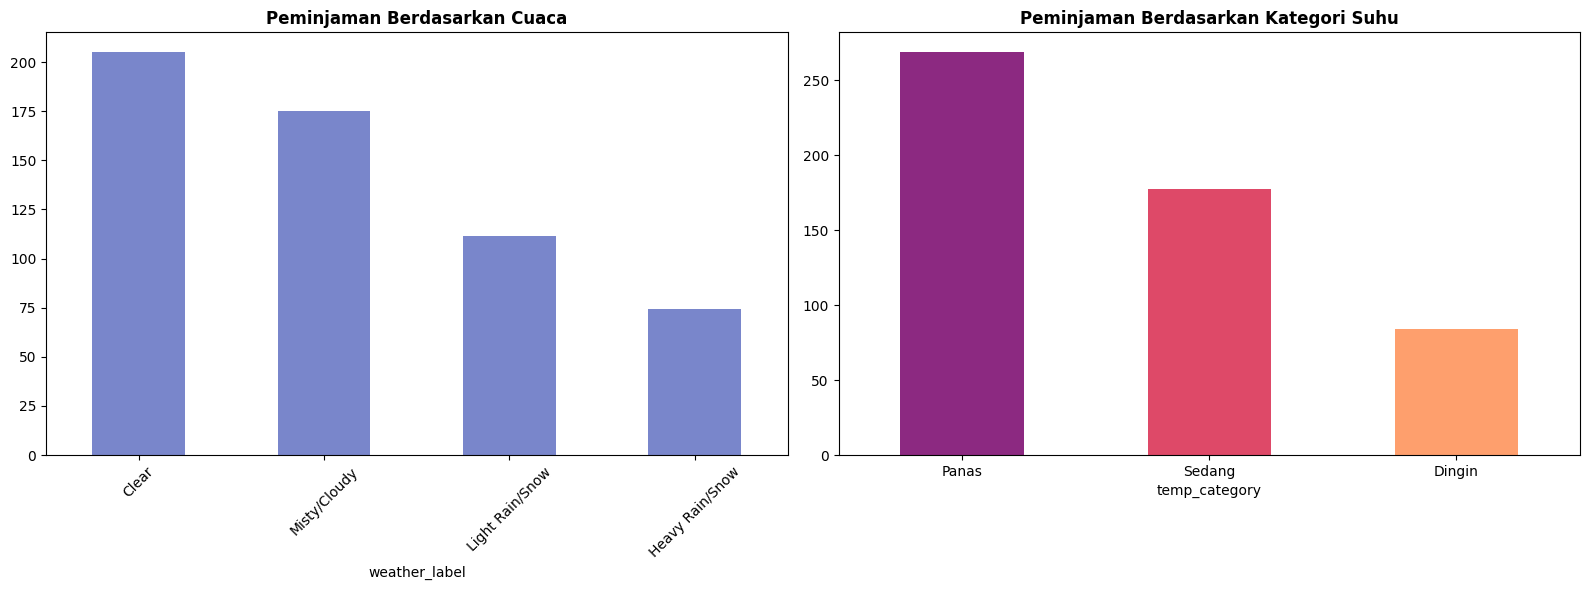

In [17]:
weather_map = {1: 'Cerah/Berawan', 2: 'Kabut/Berawan', 3: 'Hujan Ringan/Salju', 4: 'Hujan Lebat/Badai'}
if 'weather_label' not in df.columns:
    df['weather_label'] = df['weathersit'].map(weather_map)
if 'temp_category' not in df.columns:
    df['temp_category'] = pd.cut(df['temp'], bins=[0, 0.3, 0.6, 1.0], labels=['Dingin', 'Normal', 'Panas'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
weather_df = df.groupby('weather_label', observed=True)['cnt'].mean().sort_values(ascending=False)
weather_df.plot(kind='bar', ax=ax1, color='#7986CB')
ax1.set_title('Peminjaman Berdasarkan Cuaca', fontsize=12, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)

temp_df = df.groupby('temp_category', observed=True)['cnt'].mean().sort_values(ascending=False)
colors = plt.cm.magma(np.linspace(0.4, 0.8, len(temp_df)))
temp_df.plot(kind='bar', ax=ax2, color=colors)
ax2.set_title('Peminjaman Berdasarkan Kategori Suhu', fontsize=12, fontweight='bold')
ax2.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

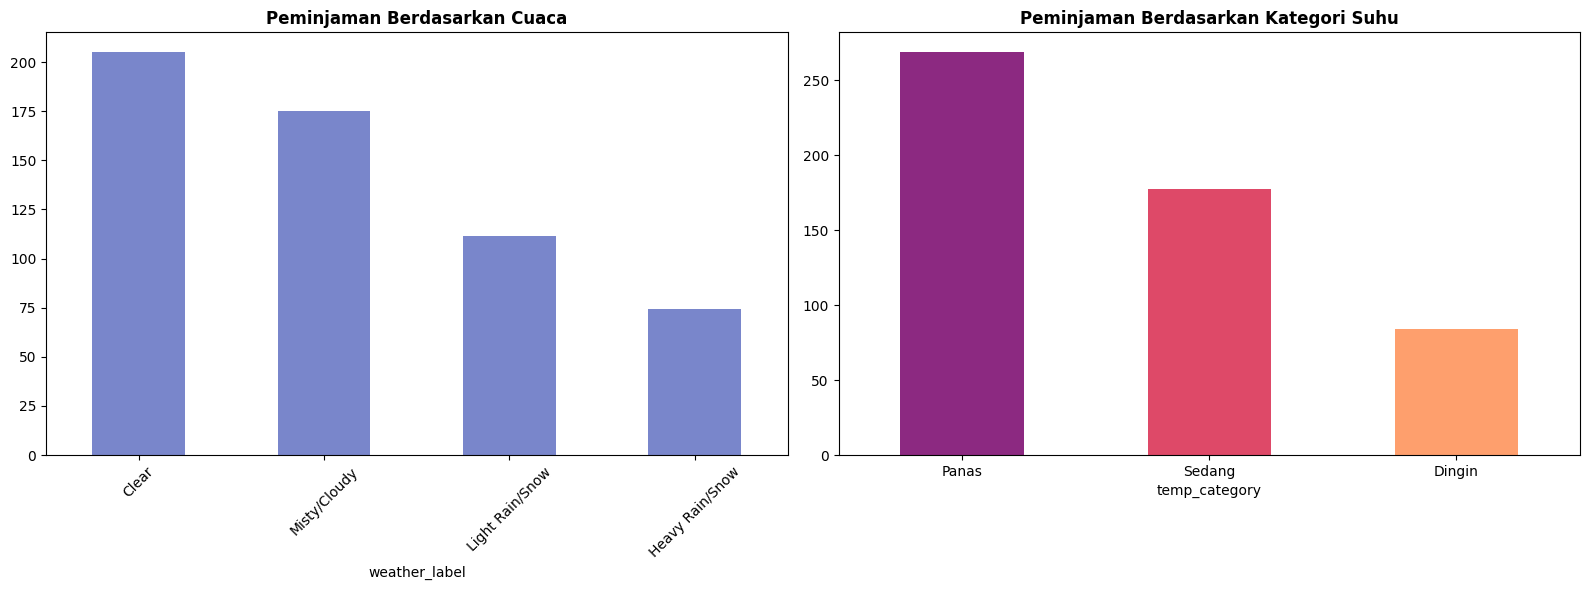

In [18]:
weather_map = {1: 'Cerah/Berawan', 2: 'Kabut/Berawan', 3: 'Hujan Ringan/Salju', 4: 'Hujan Lebat/Badai'}
if 'weather_label' not in df.columns:
    df['weather_label'] = df['weathersit'].map(weather_map)
if 'temp_category' not in df.columns:
    df['temp_category'] = pd.cut(df['temp'], bins=[0, 0.3, 0.6, 1.0], labels=['Dingin', 'Normal', 'Panas'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
weather_df = df.groupby('weather_label', observed=True)['cnt'].mean().sort_values(ascending=False)
weather_df.plot(kind='bar', ax=ax1, color='#7986CB')
ax1.set_title('Peminjaman Berdasarkan Cuaca', fontsize=12, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)

temp_df = df.groupby('temp_category', observed=True)['cnt'].mean().sort_values(ascending=False)
colors = plt.cm.magma(np.linspace(0.4, 0.8, len(temp_df)))
temp_df.plot(kind='bar', ax=ax2, color=colors)
ax2.set_title('Peminjaman Berdasarkan Kategori Suhu', fontsize=12, fontweight='bold')
ax2.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

**Insight:**
- pada pertanyaan pertama, divisualisasikan menggunakan bar chart, yang menjelaskan bahwa pengguna terdaftar meminjam sepeda lebih banyak dihari kerja dibandingkan hari libur. artinya pengguna meminjam untuk melakukan mobilitas rutin mereka. sedangkan pengguna casual lebih banyak pada hari libur, yang artinya pengguna tersebut meminjam untuk berjalan-jalan santai di hari liburnya. Selanjutnya, di visualisasi kedua menggunakan line chart menunjukkan peminjaman perjamnya. Pada hari kerja, terdapat lonjakan tajam di jam 8 pagi dan 5 sore, yang berarti jam berangkat dan pulang pengguna yang bekerja ataupun sekolah. Namun, di hari libur pengguna casual maupun terdaftar terpusat di jam 12.00-15.00.
- Pada pertanyaan ke dua, digambarkan melalui bar chart untuk melihat rata-rata peminjaman sepeda. Dari gambar tersebut, dapat dilihat bahwa  kondisi cuaca clear atau cerah memiliki angka paling tinggi. Selanjutnya, digambarkan pula melalui barchart, puncak peminjaman beradai kondisi suhu panas.

## Analisis Lanjutan (Opsional)

In [19]:
df['temp_category'] = pd.cut(df['temp'], bins=[0, 0.3, 0.6, 1.0], labels=['Dingin', 'Sedang', 'Panas'])

df['time_category'] = pd.cut(df['hr'], bins=[-1, 5, 11, 17, 23], labels=['Dini Hari', 'Pagi', 'Siang/Sore', 'Malam'])

df['season_label'] = df['season'].map({1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'})
df['day_type'] = df['workingday'].map({0: 'Hari Libur/Weekend', 1: 'Hari Kerja'})


In [20]:
df.groupby("temp_category", observed=True)["cnt"].mean().sort_values(ascending=False)

temp_category
Panas     268.663925
Sedang    177.897758
Dingin     84.378486
Name: cnt, dtype: float64

In [21]:
df.groupby(["day_type", "season_label"], observed=True)["cnt"].mean().unstack()

season_label,Fall,Spring,Summer,Winter
day_type,,,,
Hari Kerja,238.482330,119.421976,205.679387,202.185405
Hari Libur/Weekend,230.299631,95.084945,214.427401,191.925439


## Conclusion

- Conclution pertanyaan 1
terdapat perbedaan perilaku dan  kebutuhan yang sangat kontras antara pengguna casual dan pengguna terdaftar. Pengguna terdaftar lebih banyak menyewa sepeda pada hari kerja, dengan pola menanjak tajam pada jam masuk kerja (08:00) dan jam pulang kerja (17:00). hal ini membuktikan bahwa kelompok Registered menggunakan sepeda sebagai transportasi harian. sebaliknya, pengguna casual meledak hanya saat Hari Libur dengan puncak keramaian di waktu siang memanjang ke sore hari.
- Conclution pertanyaan 2
Kondisi cuaca sangat memengaruhi jumlah penyewaan. Tingkat peminjaman cenderung meningkat dan mencapai puncaknya saat cuaca cerah/clear dengan suhu yang hangat. Sebaliknya, minat penyewaan menurun secara signifikan ketika terjadi cuaca buruk, seperti hujan atau salju lebat.